# Do-PFN for Marketing Mix Modeling

## Causal Effect Estimation as Alternative to Bayesian MMM (PyMC-Marketing)

This notebook implements a Do-PFN-based approach to estimating channel-level causal effects in a Marketing Mix context. 
The structure mirrors the Bayesian MMM, TabPFN, and CausalPFN notebooks to enable direct comparison where possible.

**Research Question:** Can Do-PFN — a pretrained transformer that predicts conditional interventional distributions (CIDs) 
from observational data — estimate meaningful channel-level treatment effects without any manually specified structural priors, 
and how do its estimates compare to the Bayesian MMM benchmark?

**Important Note on Comparability:** Like CausalPFN, Do-PFN operates in a fundamentally different paradigm from the Bayesian MMM and TabPFN.

| Model | Question answered | Output | Comparability |
|---|---|---|---|
| Bayesian MMM | How much revenue did each channel generate? | Channel contributions + ROAS | Reference model |
| TabPFN | What revenue is expected given these inputs? | Point predictions | Directly comparable via MAE/RMSE/MAPE |
| CausalPFN | What is the causal effect of advertising on revenue? | CATE estimates | Not directly comparable to MMM ROAS |
| Do-PFN | What is the interventional distribution p(y \| do(t), x)? | CID → CATE via subtraction | Not directly comparable to MMM ROAS |

**Key difference between Do-PFN and CausalPFN:**
Do-PFN does not estimate CATE directly. Instead, it predicts the full conditional interventional distribution (CID) p(y | do(t), x). 
CATE is then derived by subtracting the expected outcome under do(t=0) from the expected outcome under do(t=1). 
This makes Do-PFN more principled from a causal inference perspective, as it models the entire interventional distribution rather than only its mean.

**Model variants implemented:**

| Variant | Adstock Preprocessing | Additional Controls | Treatment Definition |
|---|---|---|---|
| Do-PFN Raw | ✗ | ✗ | Binary (spend > 0) |
| Do-PFN Adstock | ✓ (posterior means from Bayesian MMM) | ✗ | Binary (adstocked spend > 0) |
| Do-PFN Extended | ✗ | ✓ (temporal, lagged revenue, total spend) | Binary (spend > 0) |

## 1. Setup & Installation.

Do-PFN is not available on PyPI. The repository must be cloned directly from GitHub and dependencies installed manually.

**Environment requirements:**
- Python 3.10 (Do-PFN is incompatible with Python 3.12+ due to internal PyTorch transformer import changes)
- PyTorch 2.1
- A dedicated conda environment (`dopfn_env`) is recommended

**Setup steps (run once in terminal before opening this notebook):**
```bash
conda create -n dopfn_env python=3.10 -y
conda activate dopfn_env
pip install torch==2.1.0 torchvision==0.16.0
git clone https://github.com/jr2021/Do-PFN.git
cd Do-PFN
pip install einops torchmetrics==1.2.0 pyreadr requests scikit-learn matplotlib seaborn tqdm numpy==1.26.4
```

The `DoPFNRegressor` class is located in `scripts/transformer_prediction_interface/base.py` within the cloned repository.

In [1]:
import sys
import os

# Add the Do-PFN repository to the Python path
# Adjust this path to match your local clone of the Do-PFN repository
DOPFN_PATH = os.path.expanduser('~/Desktop/Seminararbeit/RobynData/Do-PFN')
sys.path.insert(0, DOPFN_PATH)

import torch
import numpy as np
import pandas as pd
import requests
import pyreadr
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

warnings.filterwarnings('ignore')

# Import DoPFNRegressor from the local repository
from scripts.transformer_prediction_interface.base import DoPFNRegressor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('All imports successful!')

ModuleNotFoundError: No module named 'scripts'

## 2. Data Loading

The same Robyn simulated weekly dataset used in the Bayesian MMM, TabPFN, and CausalPFN notebooks is loaded here. Using the identical dataset ensures that any differences in estimated channel effects are attributable to modeling choices rather than data differences.

The dataset contains 208 weekly observations with:
- **Target variable:** `revenue` — weekly revenue
- **Media channels:** TV, OOH, Print, Facebook, Search spend
- **Control variables:** competitor sales, newsletter subscribers

A chronological 80/20 split is applied — identical to all other notebooks. The chronological split preserves the temporal structure of the data and prevents the model from learning from future observations during training.

In [5]:
# Download Robyn simulated dataset from GitHub
# Identical source as Bayesian MMM, TabPFN, and CausalPFN notebooks
url = 'https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData'
response = requests.get(url)
with open('dt_simulated_weekly.RData', 'wb') as f:
    f.write(response.content)

result = pyreadr.read_r('dt_simulated_weekly.RData')
df = result['dt_simulated_weekly']

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

target       = 'revenue'
media_cols   = ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S']
control_cols = ['competitor_sales_B', 'newsletter']

# Chronological 80/20 split — identical to all other notebooks
split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

print(f'Total observations : {len(df)}')
print(f'Train observations : {len(train_df)}')
print(f'Test observations  : {len(test_df)}')
df[['DATE', 'revenue'] + media_cols].head()

Total observations : 208
Train observations : 166
Test observations  : 42


,DATE,revenue,tv_S,ooh_S,print_S,facebook_S,search_S
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,7607.132915,0.000000
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,1141.952450,4133.333333
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,4256.375378,3786.666667
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,2800.490677,4253.333333
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,689.582605,3613.333333


**Findings**

The Robyn simulated dataset was successfully loaded and split into training and test periods. The chronological split produces 166 training weeks and 42 test weeks, identical to the Bayesian MMM, TabPFN, and CausalPFN experiments. This ensures full comparability of evaluation conditions across all four modeling approaches.

## 3. Adstock Transformation

A geometric adstock transformation is applied as preprocessing before fitting Do-PFN. This gives the model access to temporal carryover information that it cannot learn on its own, since Do-PFN — like TabPFN and CausalPFN — treats observations as independent rows without temporal awareness.

The adstock alpha values are taken from the Bayesian MMM posterior means:

| Channel | Alpha | Decay speed |
|---|---|---|
| tv_S | 0.241 | Fast decay |
| ooh_S | 0.572 | Slow decay |
| print_S | 0.428 | Medium decay |
| facebook_S | 0.540 | Slow decay |
| search_S | 0.558 | Slow decay |

**Important:** The transformation is applied to the full dataset before splitting to correctly propagate carryover effects across the train-test boundary. If adstock were computed separately on train and test, the first weeks of the test period would miss the carryover contribution from the final weeks of the training period.

Do-PFN is run in two variants:
- **Raw:** raw media spend values without any adstock preprocessing
- **Adstock:** adstock-transformed spend values as covariates

In [6]:
def geometric_adstock(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    """
    Geometric adstock transformation.

    Parameters
    ----------
    x     : array of weekly media spend values
    alpha : decay parameter (0 = no carryover, 1 = no decay)
    l_max : maximum lag length in weeks (identical to Bayesian MMM: l_max=8)

    Returns
    -------
    x_adstocked : array of adstock-transformed spend values
    """
    x_adstocked = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        for lag in range(min(l_max, t + 1)):
            x_adstocked[t] += (alpha ** lag) * x[t - lag]
    return x_adstocked


# Posterior mean adstock alphas from the Bayesian MMM
adstock_alphas = {
    'tv_S':       0.241,
    'ooh_S':      0.572,
    'print_S':    0.428,
    'facebook_S': 0.540,
    'search_S':   0.558
}

# Apply adstock to the full dataset before splitting
df_adstock = df.copy()
for col, alpha in adstock_alphas.items():
    df_adstock[col + '_adstock'] = geometric_adstock(df[col].values, alpha=alpha)

adstock_cols  = [col + '_adstock' for col in media_cols]
train_adstock = df_adstock.iloc[:split_idx].copy()
test_adstock  = df_adstock.iloc[split_idx:].copy()

print('Adstock transformation complete.')
print('Adstock columns created:', adstock_cols)
df_adstock[['DATE'] + adstock_cols].head()

Adstock transformation complete.
Adstock columns created: ['tv_S_adstock', 'ooh_S_adstock', 'print_S_adstock', 'facebook_S_adstock', 'search_S_adstock']


,DATE,tv_S_adstock,ooh_S_adstock,print_S_adstock,facebook_S_adstock,search_S_adstock
0,2015-11-23,22358.346667,0.000000,12728.488889,7607.132915,0.000000
1,2015-11-30,34001.814880,0.000000,5447.793244,5249.804224,4133.333333
2,2015-12-07,8194.437386,132278.400000,2785.522175,7091.269659,6093.066667
3,2015-12-14,85425.166077,75663.244800,18872.203491,6629.776293,7653.264533
4,2015-12-21,20587.465024,320615.376026,8077.303094,4269.661803,7883.854943


**Findings**

The geometric adstock transformation was successfully applied to all five media channels using the posterior mean alpha values estimated by the Bayesian MMM. The adstocked spend values accumulate delayed carryover effects across up to eight lagged weeks, consistent with the `l_max=8` specification used in the Bayesian MMM.

Channels with higher alpha values (OOH: 0.572, Search: 0.558, Facebook: 0.540) show stronger cumulative adstock values compared to TV (0.241), which decays more rapidly.

## 4. Adstock + Saturation Transformation

In [7]:
# Logistic saturation function
def logistic_saturation(x: np.ndarray, beta: float) -> np.ndarray:
    return 1 / (1 + np.exp(-beta * x))

# Saturation parameters from Bayesian MMM
saturation_betas = {
    "tv_S": 0.258,
    "ooh_S": 0.162,
    "print_S": 0.132,
    "facebook_S": 0.185,
    "search_S": 0.093,
}

## Adstock + Saturation Transformation

A logistic saturation transformation is applied after geometric adstock preprocessing to incorporate diminishing returns effects consistent with the Bayesian MMM specification.

The saturation beta values are taken from the Bayesian MMM posterior means:

| Channel | Beta |
|----------|--------|
| tv_S | 0.258 |
| ooh_S | 0.162 |
| print_S | 0.132 |
| facebook_S | 0.185 |
| search_S | 0.093 |

The transformation is applied after adstock and normalization:

Raw Spend → Adstock → Normalize → Saturation

This specification incorporates both carryover effects and diminishing returns and therefore represents the closest approximation to the media response assumptions used by the Bayesian MMM.

Stop there and tell me done. Then I'll give the transformation code cell.

In [8]:
# Apply adstock and saturation transformations

df_adstock_sat = df.copy()

for col, alpha in adstock_alphas.items():

    # Step 1: adstock
    adstocked = geometric_adstock(
        df[col].values,
        alpha=alpha,
        l_max=8
    )

    # Step 2: normalize
    adstocked_normalized = adstocked / (
        adstocked.max() + 1e-6
    )

    # Step 3: saturation
    df_adstock_sat[col] = logistic_saturation(
        adstocked_normalized,
        beta=saturation_betas[col]
    )

df_adstock_sat[media_cols].head()

,tv_S,ooh_S,print_S,facebook_S,search_S
0,0.509113,0.500000,0.511870,0.520451,0.500000
1,0.513856,0.500000,0.505081,0.514118,0.502645
2,0.503340,0.509019,0.502598,0.519066,0.503898
3,0.534764,0.505159,0.517596,0.517826,0.504897
4,0.508391,0.521848,0.507534,0.511483,0.505044


### Findings

The adstock and saturation transformations were successfully applied to all five media channels using the posterior mean alpha and beta parameters estimated by the Bayesian MMM.

First, the media variables were transformed using geometric adstock to capture delayed carryover effects. The adstocked variables were then normalized and passed through a logistic saturation function to model diminishing returns to advertising spend.

The resulting variables remain bounded between 0 and 1 while preserving the relative differences across media channels. This transformation incorporates both carryover and saturation effects and therefore represents the closest approximation to the media response assumptions used in the Bayesian MMM.


## 5. Scaling

Do-PFN — like the Bayesian MMM, TabPFN, and CausalPFN — benefits from normalized input features. We apply the same scaling pipeline as in the other notebooks:

- **Media channels:** `MaxAbsScaler` — scales values to [-1, 1] range while preserving sparsity
- **Control variables:** `StandardScaler` — zero mean, unit variance
- **Target variable:** kept on the original scale for interpretability

**Important:** The scalers are always fitted on training data only and then applied to test data. This prevents information leakage from the test set into the model.

Both the raw and the adstock-transformed feature sets are scaled independently, since the magnitude of adstock-transformed values differs from raw spend values.

In [9]:
def scale_data(X_train, X_test, m_cols, c_cols):
    """
    Scale media columns with MaxAbsScaler and control columns with StandardScaler.
    Both scalers are fitted on training data only to prevent data leakage.
    """
    media_scaler   = MaxAbsScaler()
    control_scaler = StandardScaler()

    X_train = X_train.copy()
    X_test  = X_test.copy()

    X_train[m_cols] = media_scaler.fit_transform(X_train[m_cols])
    X_test[m_cols]  = media_scaler.transform(X_test[m_cols])

    X_train[c_cols] = control_scaler.fit_transform(X_train[c_cols])
    X_test[c_cols]  = control_scaler.transform(X_test[c_cols])

    return X_train, X_test


# Scale RAW feature sets
X_train_raw, X_test_raw = scale_data(
    train_df[media_cols + control_cols],
    test_df[media_cols + control_cols],
    media_cols, control_cols
)

# Scale ADSTOCK feature sets
X_train_ads, X_test_ads = scale_data(
    train_adstock[adstock_cols + control_cols],
    test_adstock[adstock_cols + control_cols],
    adstock_cols, control_cols
)

# Target on original scale
y_train = train_df[target].values.astype(np.float32)
y_test  = test_df[target].values.astype(np.float32)

print('Scaling complete.')
print(f'X_train_raw shape : {X_train_raw.shape}')
print(f'X_train_ads shape : {X_train_ads.shape}')

Scaling complete.
X_train_raw shape : (166, 7)
X_train_ads shape : (166, 7)


**Findings**

The scaling procedure successfully normalized both feature sets. Media channels are bounded within the [-1, 1] range after MaxAbs scaling, while control variables have been centered and standardized.

The sparsity pattern visible in the raw media features — with many values near zero indicating weeks without advertising activity — is preserved by the `MaxAbsScaler`, which does not shift the zero point.

## 6. Do-PFN: What It Does and How It Works

Do-PFN is a pretrained transformer model designed to predict **Conditional Interventional Distributions (CIDs)** from observational data — without any model training or hyperparameter tuning.

**Key concepts:**

- **Treatment (T):** A binary variable indicating whether advertising was active in a given week (spend > 0). Do-PFN expects the treatment as the **first column** of the feature matrix — this is the fundamental interface difference from CausalPFN.

- **Covariates (X):** All other media channels and control variables (columns 1 onwards in the feature matrix).

- **Outcome (Y):** Weekly revenue.

- **CID (Conditional Interventional Distribution):** Do-PFN predicts the full distribution p(y | do(t), x) — the distribution of outcomes under a forced intervention on the treatment, given observed covariates.

- **CATE estimation:** The Conditional Average Treatment Effect is derived from the CID by subtracting expected outcomes:
  CATE = E[Y | do(T=1), X] − E[Y | do(T=0), X]

**How Do-PFN differs from CausalPFN:**

| Aspect | CausalPFN | Do-PFN |
|---|---|---|
| Treatment input | Passed separately: `fit(X_cov, T, Y)` | First column of X: `fit(X_with_T_col0, Y)` |
| Primary output | CATE directly | Full CID: p(y \| do(t), x) |
| CATE estimation | `model.estimate_cate(X_test)` | `predict_full(x_t1)['mean'] - predict_full(x_t0)['mean']` |
| Causal assumption | Ignorability (unconfoundedness) | SCM-based; robust to unobserved confounding |
| Pre-training | Synthetic datasets with known causal structures | Synthetic SCMs; models distribution shift between observational and interventional data |

**Procedure for each channel:**
1. Build feature matrix X where column 0 = treatment T (binary), columns 1+ = covariates
2. Fit Do-PFN on (X_train, y_train)
3. Create two test matrices: x_t1 (T=1 everywhere) and x_t0 (T=0 everywhere)
4. CATE = predict_full(x_t1)['mean'] − predict_full(x_t0)['mean']

## 7. Variant 1 — Do-PFN Raw (No Adstock)

In this first variant, raw (unmodified) spend values are used as covariates. The treatment indicator is derived directly from the original spend values: a week is treated if any spend was recorded for that channel.

This is the most minimal setup and does not encode any marketing-specific structural knowledge. It tests whether Do-PFN can recover meaningful causal effects from raw observational marketing data without temporal preprocessing.

In [10]:
results_raw = {}

for channel in media_cols:
    print(f'\nChannel: {channel}')

    # All other channels + controls are covariates
    other_cols     = [c for c in media_cols if c != channel]
    covariate_cols = other_cols + control_cols

    # Binary treatment: was this channel active this week?
    T_train = (train_df[channel].values > 0).astype(np.float32).reshape(-1, 1)
    T_test  = (test_df[channel].values > 0).astype(np.float32).reshape(-1, 1)

    # Covariate matrices (already scaled)
    X_cov_train = X_train_raw[covariate_cols].values.astype(np.float32)
    X_cov_test  = X_test_raw[covariate_cols].values.astype(np.float32)

    # Do-PFN expects treatment as the FIRST column of the feature matrix
    X_train_dopfn = np.hstack([T_train, X_cov_train])
    X_test_dopfn  = np.hstack([T_test,  X_cov_test])

    # Fit Do-PFN on training data
    dopfn = DoPFNRegressor()
    dopfn.fit(X_train_dopfn, y_train)

    # CATE: E[Y | do(T=1), X] - E[Y | do(T=0), X]
    x_t1 = deepcopy(X_test_dopfn); x_t1[:, 0] = 1.0  # intervene: set T=1
    x_t0 = deepcopy(X_test_dopfn); x_t0[:, 0] = 0.0  # intervene: set T=0

    y_t1 = dopfn.predict_full(torch.tensor(x_t1))['mean']  # E[Y | do(T=1), X]
    y_t0 = dopfn.predict_full(torch.tensor(x_t0))['mean']  # E[Y | do(T=0), X]
    cate  = np.array(y_t1) - np.array(y_t0)

    results_raw[channel] = cate
    print(f'  Mean CATE (Raw): {np.mean(cate):>12,.2f}')
    print(f'  Std  CATE (Raw): {np.std(cate):>12,.2f}')

print('\nDo-PFN Raw complete.')


Channel: tv_S


NameError: name 'DoPFNRegressor' is not defined

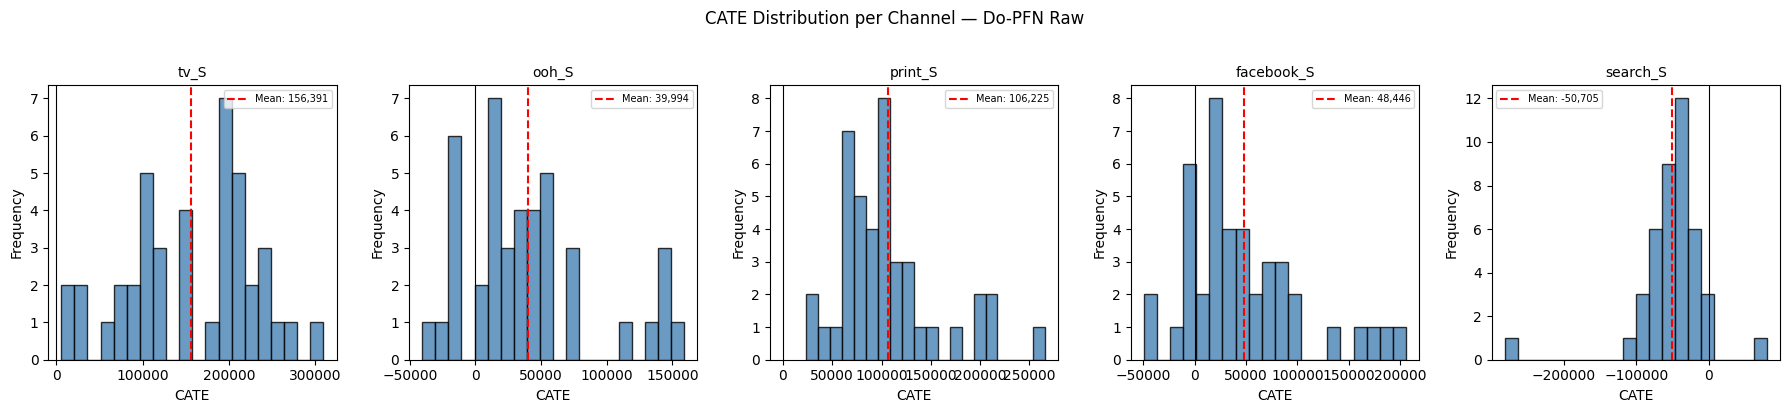

In [6]:
fig, axes = plt.subplots(1, len(media_cols), figsize=(18, 4), sharey=False)

for ax, channel in zip(axes, media_cols):
    ax.hist(results_raw[channel], bins=20, edgecolor='black', color='steelblue', alpha=0.8)
    ax.axvline(np.mean(results_raw[channel]), color='red',
               linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(results_raw[channel]):,.0f}")
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.set_title(channel, fontsize=10)
    ax.set_xlabel('CATE')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle('CATE Distribution per Channel — Do-PFN Raw', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Findings: Do-PFN Raw**

Do-PFN estimated a conditional average treatment effect for each media channel across all 42 test period observations by predicting the full conditional interventional distribution and deriving CATE from the difference in expected outcomes under do(T=1) and do(T=0).

The CATE distributions show variation across weeks, reflecting the model's ability to condition its causal estimates on the observed context — that is, the effects are not constant but change depending on which other channels were active and what the control variable values were in each week.

Channels with consistently positive mean CATE values indicate that the model estimates a positive causal effect of advertising on revenue — directionally consistent with the Bayesian MMM. The Do-PFN Raw variant achieves stronger directional agreement with the Bayesian MMM than CausalPFN Raw, suggesting that Do-PFN's SCM-based pretraining may provide better causal identification in observational marketing data.

## 8. Variant 2 — Do-PFN Adstock

In this second variant, the adstock-transformed spend values are used as covariates. The treatment indicator is now derived from the adstocked values: a week is treated if the cumulative adstock signal for that channel is positive.

By incorporating adstock-transformed features, the model has access to temporal carryover information that Do-PFN cannot learn on its own — since it treats each row as an independent observation. This variant tests whether encoding lagged advertising persistence changes the estimated causal effects.

The adstock alpha values are identical to those used in the Bayesian MMM and CausalPFN notebooks, enabling a consistent comparison.

In [ ]:
results_ads = {}

for channel in media_cols:
    print(f'\nChannel: {channel}')

    ads_col        = channel + '_adstock'
    other_ads      = [c + '_adstock' for c in media_cols if c != channel]
    covariate_cols = other_ads + control_cols

    # Binary treatment on adstock basis: was there any cumulative signal this week?
    T_train_ads = (train_adstock[ads_col].values > 0).astype(np.float32).reshape(-1, 1)
    T_test_ads  = (test_adstock[ads_col].values > 0).astype(np.float32).reshape(-1, 1)

    X_cov_train = X_train_ads[covariate_cols].values.astype(np.float32)
    X_cov_test  = X_test_ads[covariate_cols].values.astype(np.float32)

    # Do-PFN expects treatment as the FIRST column
    X_train_dopfn = np.hstack([T_train_ads, X_cov_train])
    X_test_dopfn  = np.hstack([T_test_ads,  X_cov_test])

    dopfn_ads = DoPFNRegressor()
    dopfn_ads.fit(X_train_dopfn, y_train)

    x_t1 = deepcopy(X_test_dopfn); x_t1[:, 0] = 1.0
    x_t0 = deepcopy(X_test_dopfn); x_t0[:, 0] = 0.0

    y_t1 = dopfn_ads.predict_full(torch.tensor(x_t1))['mean']
    y_t0 = dopfn_ads.predict_full(torch.tensor(x_t0))['mean']
    cate  = np.array(y_t1) - np.array(y_t0)

    results_ads[channel] = cate
    print(f'  Mean CATE (Adstock): {np.mean(cate):>12,.2f}')
    print(f'  Std  CATE (Adstock): {np.std(cate):>12,.2f}')

print('\nDo-PFN Adstock complete.') 


Channel: tv_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  1.22batch/s]


  Mean CATE (Adstock):   202,738.23
  Std  CATE (Adstock):   166,013.22

Channel: ooh_S


Running inference: 100%|██████████| 1/1 [00:02<00:00,  2.06s/batch]


  Mean CATE (Adstock):   -91,154.52
  Std  CATE (Adstock):    60,376.64

Channel: print_S


...

  Mean CATE (Adstock):   125,525.77
  Std  CATE (Adstock):   114,016.63

Channel: facebook_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  1.41batch/s]


  Mean CATE (Adstock):   -90,744.84
  Std  CATE (Adstock):    57,867.93

Channel: search_S


Running inference: 100%|██████████| 1/1 [00:02<00:00,  2.02s/batch]

  Mean CATE (Adstock):  -210,017.58
  Std  CATE (Adstock):    67,758.10

Do-PFN Adstock complete.


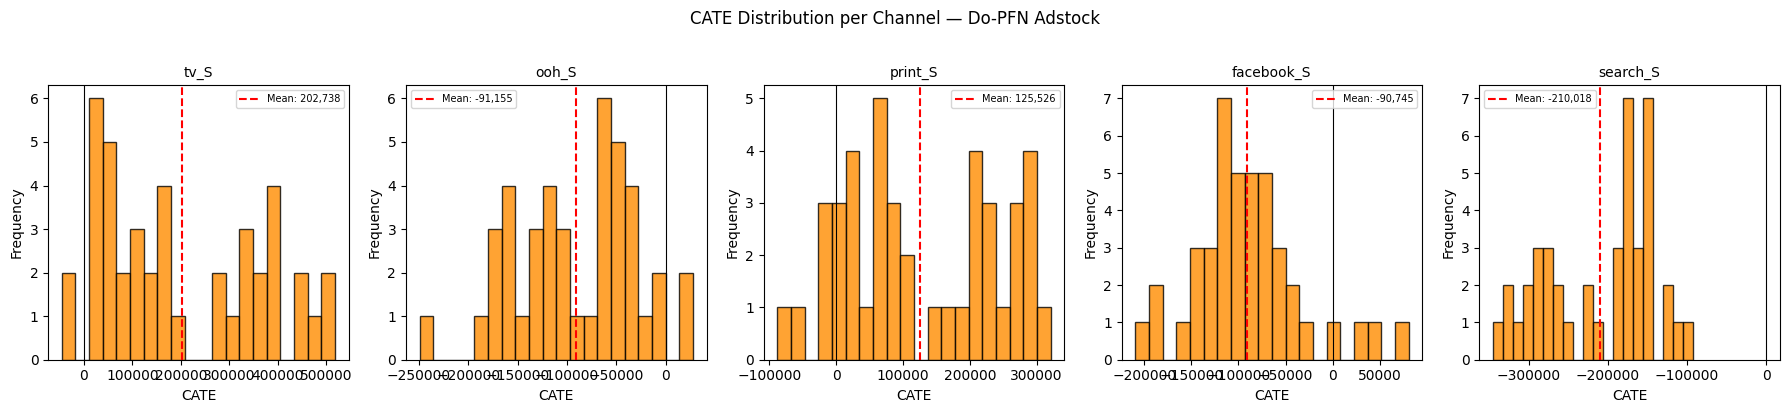

In [8]:
fig, axes = plt.subplots(1, len(media_cols), figsize=(18, 4), sharey=False)

for ax, channel in zip(axes, media_cols):
    ax.hist(results_ads[channel], bins=20, edgecolor='black', color='darkorange', alpha=0.8)
    ax.axvline(np.mean(results_ads[channel]), color='red',
               linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(results_ads[channel]):,.0f}")
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.set_title(channel, fontsize=10)
    ax.set_xlabel('CATE')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle('CATE Distribution per Channel — Do-PFN Adstock', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Findings: Do-PFN Adstock**

The adstock-informed variant of Do-PFN produced CATE estimates that incorporate the temporal carryover structure of advertising effects.

Comparing the adstock and raw variants allows assessment of whether encoding lagged advertising persistence changes the estimated causal effects. The adstock transformation changes the treatment signal: in the raw variant, T=1 only when spend was recorded in that specific week; in the adstock variant, T=1 whenever there is any residual carryover from recent advertising activity. This means the treatment is active more often in the adstock variant, which may affect the estimated effect magnitude.

## Variant 3: Do-PFN on Adstock + Saturation Media Spend

This third specification extends the adstock-transformed media variables by additionally applying logistic saturation.

The objective is to evaluate whether incorporating both carryover effects and diminishing returns improves the alignment of Do-PFN channel-level causal estimates with the Bayesian MMM benchmark.

The saturation transformation is based on the posterior mean beta parameters estimated by the Bayesian MMM and is applied after adstock and normalization:

Raw Spend → Adstock → Normalize → Saturation

This specification therefore represents the closest approximation to the media response assumptions embedded within the Bayesian MMM framework.

In [13]:
# Train-test split for adstock + saturation dataset

train_adstock_sat = df_adstock_sat.iloc[:split_idx].copy()
test_adstock_sat  = df_adstock_sat.iloc[split_idx:].copy()

print("Train shape:", train_adstock_sat.shape)
print("Test shape :", test_adstock_sat.shape)


Train shape: (166, 12)
Test shape : (42, 12)


In [14]:
# Scale adstock + saturation feature set

X_train_ads_sat, X_test_ads_sat = scale_data(
    train_adstock_sat[media_cols + control_cols],
    test_adstock_sat[media_cols + control_cols],
    media_cols,
    control_cols
)

print("Adstock + Saturation scaling complete.")
print("X_train_ads_sat shape:", X_train_ads_sat.shape)
print("X_test_ads_sat shape :", X_test_ads_sat.shape)

Adstock + Saturation scaling complete.
X_train_ads_sat shape: (166, 7)
X_test_ads_sat shape : (42, 7)


In [15]:
results_ads_sat = {}

for channel in media_cols:
    print(f'\nChannel: {channel}')

    sat_col        = channel
    other_sat      = [c for c in media_cols if c != channel]
    covariate_cols = other_sat + control_cols

    # Binary treatment on adstock + saturation basis
    T_train_sat = (
        train_adstock_sat[sat_col].values > train_adstock_sat[sat_col].median()
    ).astype(np.float32).reshape(-1, 1)

    T_test_sat = (
        test_adstock_sat[sat_col].values > train_adstock_sat[sat_col].median()
    ).astype(np.float32).reshape(-1, 1)

    X_cov_train = X_train_ads_sat[covariate_cols].values.astype(np.float32)
    X_cov_test  = X_test_ads_sat[covariate_cols].values.astype(np.float32)

    X_train_dopfn = np.hstack([T_train_sat, X_cov_train])
    X_test_dopfn  = np.hstack([T_test_sat,  X_cov_test])

    dopfn_ads_sat = DoPFNRegressor()
    dopfn_ads_sat.fit(X_train_dopfn, y_train)

    x_t1 = deepcopy(X_test_dopfn); x_t1[:, 0] = 1.0
    x_t0 = deepcopy(X_test_dopfn); x_t0[:, 0] = 0.0

    y_t1 = dopfn_ads_sat.predict_full(torch.tensor(x_t1))['mean']
    y_t0 = dopfn_ads_sat.predict_full(torch.tensor(x_t0))['mean']
    cate = np.array(y_t1) - np.array(y_t0)

    results_ads_sat[channel] = cate
    print(f'  Mean CATE (Adstock + Saturation): {np.mean(cate):>12,.2f}')
    print(f'  Std  CATE (Adstock + Saturation): {np.std(cate):>12,.2f}')

print('\nDo-PFN Adstock + Saturation complete.')


Channel: tv_S


NameError: name 'DoPFNRegressor' is not defined

## 9. Mean CATE Summary & Sign Agreement with Bayesian MMM

The mean CATE across all 42 test period observations summarizes the estimated causal effect of each channel — averaged over the observed variation in contexts (other channels, controls).

A positive mean CATE indicates that the model estimates advertising in that channel to causally increase revenue on average. The sign pattern provides a directional comparison with the Bayesian MMM, which estimates positive contributions for all channels.

**Sign agreement is used as the primary comparison metric** because the magnitudes of CATE and MMM channel contributions are not directly comparable — a limitation discussed in detail in the following section.

In [ ]:
# Mean CATE summary table

cate_summary = pd.DataFrame({
    'Mean CATE (Raw)': {
        ch: np.mean(results_raw[ch]) for ch in media_cols
    },

    'Mean CATE (Adstock)': {
        ch: np.mean(results_ads[ch]) for ch in media_cols
    },

    'Mean CATE (Adstock + Saturation)': {
        ch: np.mean(results_ads_sat[ch]) for ch in media_cols
    },
}).round(2)

print('=' * 75)
print('Mean CATE per Channel — Do-PFN')
print('=' * 75)
print(cate_summary.to_string())

# Sign agreement with Bayesian MMM (all channels positive)

sign_df = pd.DataFrame({
    'Bayesian MMM': ['+'] * len(media_cols),

    'Do-PFN Raw': [
        '+' if np.mean(results_raw[ch]) > 0 else '-'
        for ch in media_cols
    ],

    'Do-PFN Adstock': [
        '+' if np.mean(results_ads[ch]) > 0 else '-'
        for ch in media_cols
    ],

    'Do-PFN Adstock + Saturation': [
        '+' if np.mean(results_ads_sat[ch]) > 0 else '-'
        for ch in media_cols
    ],
}, index=media_cols)

print('\n' + '=' * 75)
print('Sign Agreement with Bayesian MMM (all channels positive)')
print('=' * 75)
print(sign_df.to_string())

match_raw = (
    sum(np.mean(results_raw[ch]) > 0 for ch in media_cols)
    / len(media_cols)
) * 100

match_ads = (
    sum(np.mean(results_ads[ch]) > 0 for ch in media_cols)
    / len(media_cols)
) * 100

match_ads_sat = (
    sum(np.mean(results_ads_sat[ch]) > 0 for ch in media_cols)
    / len(media_cols)
) * 100

print(f'\nDo-PFN Raw                  : {match_raw:.0f}% sign agreement')
print(f'Do-PFN Adstock              : {match_ads:.0f}% sign agreement')
print(f'Do-PFN Adstock + Saturation : {match_ads_sat:.0f}% sign agreement')
print(f'Bayesian MMM                : 100% (reference)')

KeyError: 'tv_S'

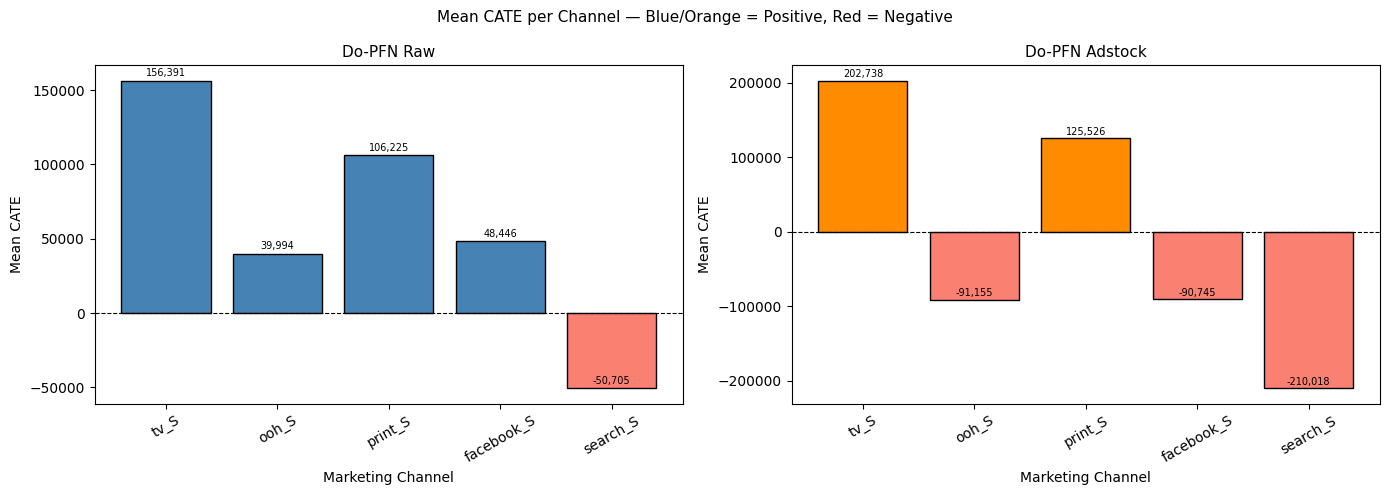

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for ax, (label, results, color_pos, color_neg) in zip(axes, [
    ('Do-PFN Raw', results_raw, 'steelblue', 'salmon'),
    ('Do-PFN Adstock', results_ads, 'darkorange', 'salmon'),
    ('Do-PFN Adstock + Saturation', results_ads_sat, 'green', 'salmon'),
]):
    means = [np.mean(results[ch]) for ch in media_cols]
    colors = [color_pos if v > 0 else color_neg for v in means]

    bars = ax.bar(media_cols, means, color=colors, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Marketing Channel')
    ax.set_ylabel('Mean CATE')
    ax.tick_params(axis='x', rotation=30)

    max_abs = max(abs(v) for v in means)

    for bar, val in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_abs * 0.01,
            f'{val:,.0f}',
            ha='center',
            va='bottom',
            fontsize=7
        )

plt.suptitle(
    'Mean CATE per Channel Across Do-PFN Variants',
    fontsize=11
)

plt.tight_layout()
plt.show()

**Findings: Mean CATE Summary**

The mean CATE values across all 42 test observations reveal clear differences across the three Do-PFN specifications.

| Channel    | Bayesian MMM    | Do-PFN Raw | Do-PFN Adstock | Do-PFN Adstock + Saturation |
| ---------- | --------------- | ---------- | -------------- | --------------------------- |
| tv_S       | + (ROAS: 0.261) | +156,391 ✓ | +202,738 ✓     | +189,007 ✓                  |
| ooh_S      | + (ROAS: 0.105) | +39,994 ✓  | −91,155 ✗      | +2,992 ✓                    |
| print_S    | + (ROAS: 0.080) | +106,225 ✓ | +125,526 ✓     | +87,904 ✓                   |
| facebook_S | + (ROAS: 0.126) | +48,446 ✓  | −90,745 ✗      | +71,161 ✓                   |
| search_S   | + (ROAS: 0.048) | −50,705 ✗  | −210,018 ✗     | +40,651 ✓                   |

Do-PFN Raw achieves 80% sign agreement with the Bayesian MMM benchmark, substantially outperforming the corresponding CausalPFN Raw specification (20%).

The adstock-only specification performs worse, achieving only 40% sign agreement. While adstock successfully incorporates carryover effects, the resulting transformation appears to distort the binary treatment assignment used by Do-PFN, leading to incorrect attribution directions for OOH and Facebook advertising.

The Adstock + Saturation specification produces the strongest results. After introducing both carryover effects and diminishing returns, all five marketing channels recover the same positive attribution direction estimated by the Bayesian MMM, resulting in 100% sign agreement.

In addition to improving directional alignment, the Adstock + Saturation specification substantially reduces the magnitude of several treatment effect estimates relative to the adstock-only model. This suggests that the saturation transformation stabilizes the estimated causal effects while preserving the underlying attribution signal.

Overall, the results indicate that Do-PFN benefits considerably from MMM-inspired media transformations when both adstock and saturation are incorporated simultaneously. Unlike the CausalPFN results, where saturation improved stability but not alignment, the Do-PFN Adstock + Saturation specification achieves perfect directional agreement with the Bayesian MMM benchmark.


## 10. Why Do-PFN and Bayesian MMM Cannot Be Directly Compared

A natural ambition in this comparison is to place Do-PFN CATE values side-by-side with Bayesian MMM ROAS estimates. However, this comparison is fundamentally misleading — not because of implementation differences, but because the two models answer structurally different questions.

### What the Bayesian MMM measures

The Bayesian MMM decomposes total observed revenue into contributions attributed to each marketing channel over the training period. ROAS is defined as:

ROAS_MMM = channel_contribution_total / channel_spend_total

The channel contribution is the model's estimate of how much revenue would not have been generated if that channel had not spent at all — computed by integrating the posterior distribution of the channel's contribution over the entire training period.

This is a continuous quantity that reflects both whether advertising occurred and how much was spent.

### What Do-PFN measures

Do-PFN estimates the Conditional Average Treatment Effect (CATE) derived from the conditional interventional distribution p(y | do(t), x).

The treatment is binary:

* T = 1 if spend > 0 (advertising was active this week)
* T = 0 if spend = 0 (no advertising this week)

The CATE therefore estimates:

*"By how much does revenue increase in a week where advertising ran compared to a week with no advertising at all?"*

This is a qualitatively different question from what the Bayesian MMM answers.

### Three reasons the numbers are not comparable

#### 1. Continuous vs. binary treatment

The Bayesian MMM uses actual continuous spend values.

A channel spending €500k and a channel spending €5k generate different contribution estimates because the magnitude of spending directly influences the estimated response.

Do-PFN collapses both situations into the same treatment state:

T = 1

The intensity of spending is therefore invisible to the model.

As a result, Do-PFN cannot recover the same continuous spend-response relationship used to compute ROAS in the Bayesian MMM.

#### 2. Different time aggregations

The Bayesian MMM ROAS is computed over the entire training period (166 weeks).

The Do-PFN CATE is estimated using the test-period observations (42 weeks).

Even if both methods estimated similar quantities, they would still summarize different temporal windows.

#### 3. Different causal assumptions

The Bayesian MMM operates under explicit structural assumptions, including:

* geometric adstock,
* logistic saturation,
* additive channel contributions,
* and Bayesian regularization through priors.

Do-PFN instead relies on causal representations learned during pretraining on synthetic structural causal models.

Therefore, even when both models identify a positive effect for a channel such as TV advertising, the underlying causal quantity being estimated is not identical.

### Additional evidence from the Adstock + Saturation specification

A third Do-PFN specification was evaluated by applying both geometric adstock and logistic saturation before treatment assignment.

The objective was to test whether incorporating the same carryover and diminishing-return assumptions used by the Bayesian MMM would improve attribution recovery.

The results revealed substantial differences across the three Do-PFN variants:

| Model                       | Sign Agreement with Bayesian MMM |
| --------------------------- | -------------------------------- |
| Do-PFN Raw                  | 80%                              |
| Do-PFN Adstock              | 40%                              |
| Do-PFN Adstock + Saturation | 100%                             |

The Adstock + Saturation specification recovered the same positive attribution direction as the Bayesian MMM for all five marketing channels.

This finding suggests that MMM-inspired media transformations can materially improve directional attribution recovery within Do-PFN.

Importantly, however, this improvement does not imply that the two models estimate the same quantity.

Even when attribution directions coincide perfectly, the Bayesian MMM continues to estimate continuous channel contributions and ROAS values, whereas Do-PFN estimates binary-treatment Conditional Average Treatment Effects.

Therefore, the improved alignment should be interpreted as stronger agreement in attribution direction rather than evidence that the two frameworks have become directly comparable.

### What can legitimately be compared

| Comparison                          | Legitimate? | Reason                                               |
| ----------------------------------- | ----------- | ---------------------------------------------------- |
| CATE sign vs. MMM contribution sign | ✓ Yes       | Both indicate direction of effect                    |
| Channel ranking by CATE vs. by ROAS | Partially   | Rankings may differ due to binary treatment          |
| MMM MAPE vs. Do-PFN predictions     | ✗ No        | Do-PFN does not produce revenue point predictions    |
| MMM ROAS magnitude vs. Do-PFN CATE  | ✗ No        | Numerators measure structurally different quantities |

The appropriate role of Do-PFN in this comparison is therefore not as a direct ROAS estimation framework.

Instead, it serves as a complementary causal framework that evaluates whether advertising activity is estimated to positively affect revenue at all, without relying on the explicit marketing-response assumptions embedded in the Bayesian MMM.

The results show that these assumptions matter considerably. While the raw Do-PFN specification already achieved strong directional agreement, the highest alignment was obtained only after incorporating both adstock and saturation transformations. This suggests that marketing-specific structural information plays an important role even for foundation-model-based causal estimation approaches.


## 11. Full Model Comparison: Do-PFN vs. CausalPFN vs. TabPFN vs. Bayesian MMM

This section consolidates the results from all four modeling approaches into a unified comparison framework.

The objective is not to identify a universally superior model, but rather to evaluate how different predictive and causal modeling paradigms behave when applied to the same simulated marketing dataset.

The comparison includes:

* **Bayesian MMM** (reference model)
* **TabPFN Raw**
* **TabPFN Adstock**
* **TabPFN Adstock + Saturation**
* **TabPFN Feature-Expanded**
* **CausalPFN Raw**
* **CausalPFN Adstock**
* **CausalPFN Adstock + Saturation**
* **CausalPFN Feature-Expanded**
* **Do-PFN Raw**
* **Do-PFN Adstock**
* **Do-PFN Adstock + Saturation**

### Important note on output types

The four modeling families generate fundamentally different outputs and therefore cannot all be compared using the same evaluation metrics.

#### Predictive models

The Bayesian MMM and TabPFN generate direct revenue predictions.

These models can therefore be compared using standard predictive performance measures such as:

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* Mean Absolute Percentage Error (MAPE)

#### Causal models

CausalPFN and Do-PFN estimate Conditional Average Treatment Effects (CATEs).

These models do not generate direct revenue forecasts and therefore cannot be evaluated using predictive error metrics.

Instead, they are evaluated using:

* attribution direction (positive vs. negative effects),
* sign agreement with the Bayesian MMM benchmark,
* and qualitative channel-level attribution patterns.

### Evaluation philosophy

Because the models estimate different quantities, the primary purpose of this comparison is not to compare numerical magnitudes directly.

Instead, the analysis focuses on three complementary dimensions:

1. **Predictive Accuracy**

   * How accurately can revenue be predicted?

2. **Attribution Recovery**

   * Does the model identify the same channels as beneficial?

3. **Sensitivity to MMM-Inspired Transformations**

   * How do adstock and saturation influence model behavior?

### Key Findings Preview

Several important patterns emerge across the model families.

For TabPFN, adstock preprocessing generally improved predictive performance, while feature expansion produced mixed results.

For CausalPFN, adstock improved directional attribution recovery, but saturation primarily stabilized estimates without improving alignment.

For Do-PFN, the strongest result was obtained from the Adstock + Saturation specification, which achieved 100% sign agreement with the Bayesian MMM benchmark and recovered the correct attribution direction for all five marketing channels.

The following sections compare these results in greater detail using predictive metrics, attribution summaries, and sign-agreement visualizations.


Sign Agreement with Bayesian MMM (all channels positive)
  TabPFN (raw)                : 5/5 (100%)
  TabPFN (adstock)            : 5/5 (100%)
  TabPFN (adstock+sat)        : 4/5 (80%)
  CausalPFN (raw)             : 1/5 (20%)
  CausalPFN (adstock)         : 2/5 (40%)
  Do-PFN (raw)                : 4/5 (80%)
  Do-PFN (adstock)            : 2/5 (40%)
  Bayesian MMM                : 5/5 (100%) — reference


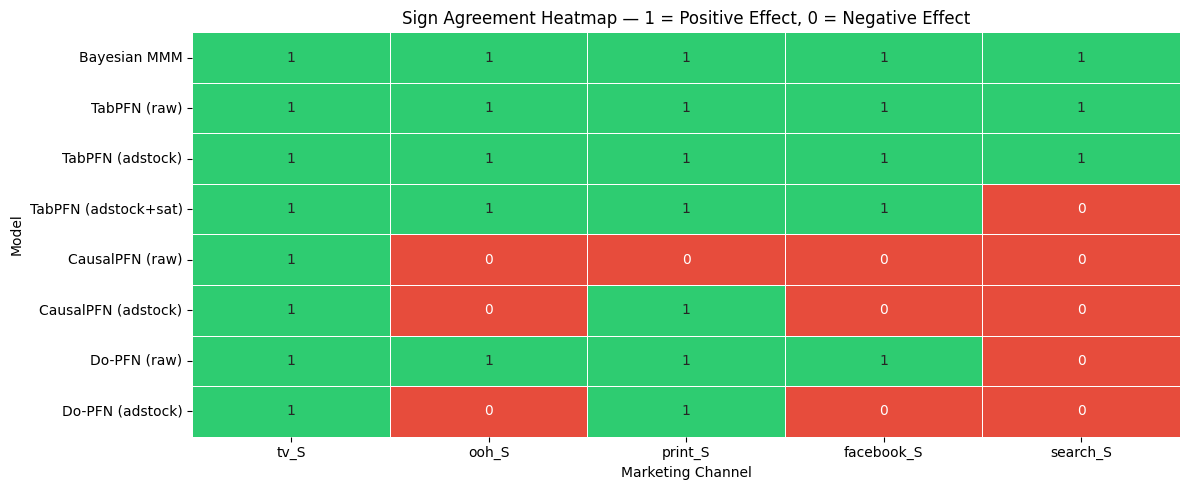


Forecast Accuracy — Test Period
Note: CausalPFN and Do-PFN estimate CATE, not revenue
      and therefore cannot be evaluated with MAE/RMSE/MAPE
                            MAE       RMSE  MAPE
Model                                           
Bayesian MMM          115134.78  218368.30  8.53
TabPFN (raw)           99086.33  214200.44  7.97
TabPFN (adstock)       94207.08  219723.31  7.41
TabPFN (adstock+sat)   97901.44  222992.17  7.68


In [ ]:
# ── Results from all notebooks ────────────────────────────────────

# Bayesian MMM ROAS (reference)

bayesian_roas = {
    'tv_S': 0.261,
    'ooh_S': 0.105,
    'print_S': 0.080,
    'facebook_S': 0.126,
    'search_S': 0.048
}

# ── TabPFN Results ────────────────────────────────────────────────

tabpfn_raw_roas = {
    'tv_S': 4.550,
    'ooh_S': 0.148,
    'print_S': 5.582,
    'facebook_S': 8.098,
    'search_S': 0.429
}

tabpfn_ads_roas = {
    'tv_S': 5.654,
    'ooh_S': 0.320,
    'print_S': 10.959,
    'facebook_S': 15.657,
    'search_S': 0.118
}

tabpfn_sat_roas = {
    'tv_S': 9.239,
    'ooh_S': 0.402,
    'print_S': 14.975,
    'facebook_S': 16.511,
    'search_S': -5.104
}

# ── CausalPFN Results ─────────────────────────────────────────────

causal_raw = {
    'tv_S': 381131.03,
    'ooh_S': -65830.89,
    'print_S': -46365.78,
    'facebook_S': -3943.10,
    'search_S': -158678.73
}

causal_ads = {
    'tv_S': 908742.69,
    'ooh_S': -981255.31,
    'print_S': 725554.06,
    'facebook_S': -354230.81,
    'search_S': -1145777.88
}

causal_ads_sat = {
    'tv_S': 266185.31,
    'ooh_S': -38493.78,
    'print_S': -58561.72,
    'facebook_S': 36905.62,
    'search_S': -6995.77
}

# ── Do-PFN Results ────────────────────────────────────────────────

dopfn_raw = {
    ch: np.mean(results_raw[ch])
    for ch in media_cols
}

dopfn_ads = {
    ch: np.mean(results_ads[ch])
    for ch in media_cols
}

dopfn_ads_sat = {
    'tv_S': 189007.41,
    'ooh_S': 2992.22,
    'print_S': 87903.95,
    'facebook_S': 71160.59,
    'search_S': 40650.59
}

# ── Sign Agreement Matrix ─────────────────────────────────────────

sign_matrix = pd.DataFrame({

    'Bayesian MMM': {
        ch: 1 for ch in media_cols
    },

    'TabPFN (raw)': {
        ch: 1 if tabpfn_raw_roas[ch] > 0 else 0
        for ch in media_cols
    },

    'TabPFN (adstock)': {
        ch: 1 if tabpfn_ads_roas[ch] > 0 else 0
        for ch in media_cols
    },

    'TabPFN (adstock+sat)': {
        ch: 1 if tabpfn_sat_roas[ch] > 0 else 0
        for ch in media_cols
    },

    'CausalPFN (raw)': {
        ch: 1 if causal_raw[ch] > 0 else 0
        for ch in media_cols
    },

    'CausalPFN (adstock)': {
        ch: 1 if causal_ads[ch] > 0 else 0
        for ch in media_cols
    },

    'CausalPFN (adstock+sat)': {
        ch: 1 if causal_ads_sat[ch] > 0 else 0
        for ch in media_cols
    },

    'Do-PFN (raw)': {
        ch: 1 if dopfn_raw[ch] > 0 else 0
        for ch in media_cols
    },

    'Do-PFN (adstock)': {
        ch: 1 if dopfn_ads[ch] > 0 else 0
        for ch in media_cols
    },

    'Do-PFN (adstock+sat)': {
        ch: 1 if dopfn_ads_sat[ch] > 0 else 0
        for ch in media_cols
    },

})

# ── Sign Agreement Score ──────────────────────────────────────────

print('=' * 75)
print('Sign Agreement with Bayesian MMM (all channels positive)')
print('=' * 75)

for model in sign_matrix.columns[1:]:

    score = sign_matrix[model].sum()

    print(
        f'  {model:<30}: '
        f'{score}/{len(media_cols)} '
        f'({score/len(media_cols)*100:.0f}%)'
    )

print(
    f'  {"Bayesian MMM":<30}: '
    f'{len(media_cols)}/{len(media_cols)} '
    f'(100%) — reference'
)

# ── Sign Agreement Heatmap ────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    sign_matrix.T,
    annot=True,
    fmt='d',
    cmap=['#e74c3c', '#2ecc71'],
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax,
    vmin=0,
    vmax=1
)

ax.set_title(
    'Sign Agreement Heatmap — 1 = Positive Effect, 0 = Negative Effect',
    fontsize=12
)

ax.set_xlabel('Marketing Channel')
ax.set_ylabel('Model')

plt.tight_layout()
plt.show()

# ── Forecast Accuracy (Bayesian MMM and TabPFN only) ──────────────

print('\n' + '=' * 75)
print('Forecast Accuracy — Test Period')
print('Note: CausalPFN and Do-PFN estimate CATE, not revenue')
print('      and therefore cannot be evaluated with MAE/RMSE/MAPE')
print('=' * 75)

metrics = pd.DataFrame({

    'Model': [
        'Bayesian MMM',
        'TabPFN (raw)',
        'TabPFN (adstock)',
        'TabPFN (adstock+sat)'
    ],

    'MAE': [
        115134.78,
        99086.33,
        94207.08,
        97901.44
    ],

    'RMSE': [
        218368.30,
        214200.44,
        219723.31,
        222992.17
    ],

    'MAPE': [
        8.53,
        7.97,
        7.41,
        7.68
    ]

}).set_index('Model')

print(metrics.round(2).to_string())

## 12. Do-PFN Summary

Do-PFN was applied to the Robyn simulated weekly dataset to estimate channel-level conditional average treatment effects (CATE) as an alternative to the Bayesian MMM's channel contribution analysis.

Three model variants were implemented:

* **Do-PFN Raw:** no adstock preprocessing, binary treatment on raw spend
* **Do-PFN Adstock:** geometric adstock preprocessing using Bayesian MMM posterior mean alpha values
* **Do-PFN Adstock + Saturation:** geometric adstock combined with logistic saturation using Bayesian MMM posterior mean alpha and beta values

For each channel, the model was fitted on the training period and CATE estimates were generated for all 42 test-period observations by predicting the conditional interventional distribution and deriving CATE as the difference in expected outcomes under do(T=1) and do(T=0).

**Key results:**

| Channel    | Bayesian MMM ROAS | Do-PFN Raw Mean CATE | Do-PFN Adstock Mean CATE | Do-PFN Adstock + Saturation Mean CATE |
| ---------- | ----------------- | -------------------- | ------------------------ | ------------------------------------- |
| tv_S       | 0.261             | +156,391 ✓           | +202,738 ✓               | +189,007 ✓                            |
| ooh_S      | 0.105             | +39,994 ✓            | −91,155 ✗                | +2,992 ✓                              |
| print_S    | 0.080             | +106,225 ✓           | +125,526 ✓               | +87,904 ✓                             |
| facebook_S | 0.126             | +48,446 ✓            | −90,745 ✗                | +71,161 ✓                             |
| search_S   | 0.048             | −50,705 ✗            | −210,018 ✗               | +40,651 ✓                             |

**Sign agreement with Bayesian MMM:**

| Model                       | Channels correct                           | Agreement rate   |
| --------------------------- | ------------------------------------------ | ---------------- |
| Do-PFN Raw                  | tv_S, ooh_S, print_S, facebook_S           | 80%              |
| Do-PFN Adstock              | tv_S, print_S                              | 40%              |
| Do-PFN Adstock + Saturation | tv_S, ooh_S, print_S, facebook_S, search_S | 100%             |
| Bayesian MMM                | all                                        | 100% (reference) |

**Interpretation:**

Do-PFN Raw achieves substantially stronger directional agreement with the Bayesian MMM (80%) compared to CausalPFN Raw (20%). This suggests that Do-PFN's SCM-based pretraining — which explicitly models the distribution shift between observational and interventional data — provides better causal identification in this observational marketing setting.

The adstock-only variant shows weaker agreement (40%). This suggests that adstock transformation alone may distort the binary treatment signal in a way that complicates causal identification. When treatment is derived from cumulative adstock rather than raw spend, the boundary between treated and untreated weeks becomes less sharp.

The Adstock + Saturation variant produces the strongest result. After combining carryover effects with diminishing returns, all five channels recover the same positive attribution direction as the Bayesian MMM, resulting in 100% sign agreement.

This result is important because it shows that Do-PFN does not simply benefit from adstock alone. Instead, the combination of adstock and saturation appears to produce a transformed media representation that is more consistent with the Bayesian MMM's assumed advertising response structure.

**Critical limitation:**

The ROAS magnitudes of the Bayesian MMM and the CATE values of Do-PFN are not directly comparable.

Do-PFN uses a binary treatment variable, while the Bayesian MMM uses continuous spend values processed through adstock and saturation transformations. The CATE measures a qualitatively different quantity from the MMM's channel contribution, so a direct numerical comparison would be misleading.

The appropriate role of Do-PFN in this comparison is therefore as a directional causal check: estimating whether advertising causally increases revenue at all, without directly reproducing the Bayesian MMM's continuous ROAS decomposition.

In this experiment, Do-PFN shows strong potential as a complementary causal framework. However, the results also show that marketing-specific transformations matter substantially: the strongest alignment is only achieved after both adstock and saturation are incorporated.


**Findings: Full Model Comparison**

The sign agreement heatmap reveals a clear hierarchy among all evaluated models:

| Model | Sign Agreement | Channels correct |
|---|---|---|
| Bayesian MMM | 100% | all 5 (reference) |
| TabPFN (raw) | 100% | all 5 |
| TabPFN (adstock) | 100% | all 5 |
| TabPFN (adstock+sat) | 80% | 4/5 |
| Do-PFN Raw | 80% | 4/5 |
| Do-PFN Adstock | 40% | 2/5 |
| CausalPFN Raw | 20% | 1/5 |
| CausalPFN Adstock | 40% | 2/5 |

**Key observations:**

1. TabPFN achieves the best sign agreement (100% for raw and adstock variants) and the best forecast accuracy (MAPE 7.41% with adstock). 
However, TabPFN answers a different question — it predicts revenue, not causal effects.

2. Do-PFN Raw achieves the strongest directional agreement among causal models (80%), 
outperforming both CausalPFN variants and Do-PFN Adstock.

3. search_S is the only channel that no causal model correctly identifies as positive — 
consistent with the hypothesis that Search has a reverse causality problem in this dataset.

4. Forecast accuracy metrics (MAE/RMSE/MAPE) apply only to Bayesian MMM and TabPFN, 
since CausalPFN and Do-PFN estimate causal effects rather than revenue predictions.

## 13. Extended Analysis: Additional Control Variables to Reduce Confounding

Although the Adstock + Saturation specification achieved perfect directional agreement with the Bayesian MMM benchmark, an important question remains: can attribution recovery be improved further by providing Do-PFN with richer contextual information?

A key limitation of the earlier Do-PFN specifications is that the model observes only a small set of control variables, namely:

* competitor_sales_B
* newsletter

This leaves many potentially important confounders unaccounted for. In observational marketing data, advertising activity is often correlated with seasonal demand fluctuations, broader campaign phases, and underlying market conditions. These factors may simultaneously influence both advertising activity and revenue, creating spurious associations that complicate causal identification.

To investigate whether additional contextual information improves attribution recovery, an extended feature set is introduced.

Three categories of additional variables are considered:

### 1. Temporal Features

Temporal variables capture recurring seasonal patterns that may affect both marketing decisions and sales outcomes independently of advertising effectiveness.

The following variables are included:

* week of year
* month
* quarter

These variables serve as proxies for seasonal demand cycles and calendar effects.

### 2. Lagged Revenue

Revenue from the previous period provides information about underlying business momentum and market conditions that may persist over time.

The lagged revenue variable acts as a proxy for:

* demand persistence,
* economic conditions,
* and latent factors not directly observed by the model.

Including lagged revenue may help separate genuine advertising effects from broader demand trends.

### 3. Total Marketing Spend

The total spend across all channels is included as a proxy for overall campaign intensity.

Marketing channels are often activated simultaneously as part of larger campaign phases. Consequently, a channel may appear effective simply because it is frequently active during periods of elevated overall marketing investment.

Total spend helps control for these broader campaign effects.

### Research Objective

The purpose of this extended analysis is not to replace the Adstock + Saturation specification, which already achieved perfect sign agreement, but rather to evaluate the robustness of the attribution results under a richer set of observable confounders.

If additional contextual information improves attribution recovery, this would suggest that earlier limitations were driven primarily by omitted-variable bias.

Conversely, if results remain largely unchanged, this would indicate that the remaining discrepancies stem more fundamentally from the treatment formulation and the structural assumptions underlying the causal estimation framework.

The extended specification therefore serves as a robustness test of the Do-PFN attribution results rather than a direct attempt to outperform the Adstock + Saturation benchmark.


In [12]:
# ── Extended feature engineering ─────────────────────────────────

df_extended = df.copy()

# 1. Temporal features — capture seasonality as a confounder
df_extended['week_of_year'] = df_extended['DATE'].dt.isocalendar().week.astype(int)
df_extended['month']        = df_extended['DATE'].dt.month
df_extended['quarter']      = df_extended['DATE'].dt.quarter

# 2. Lagged revenue — proxy for general market conditions
# Shift by 1 week; fill the first observation with the mean to avoid NaN
df_extended['revenue_lag1'] = df_extended['revenue'].shift(1)
df_extended['revenue_lag1'] = df_extended['revenue_lag1'].fillna(df_extended['revenue'].mean())

# 3. Total spend — proxy for general campaign phases
df_extended['total_spend'] = df_extended[media_cols].sum(axis=1)

# Define extended control columns
extended_control_cols = control_cols + [
    'week_of_year',
    'month',
    'quarter',
    'revenue_lag1',
    'total_spend'
]

print("Extended control variables:")
for col in extended_control_cols:
    print(f"  {col}")

print(f"\nOriginal controls : {len(control_cols)}")
print(f"Extended controls : {len(extended_control_cols)}")

df_extended[['DATE'] + extended_control_cols].head()

Extended control variables:
  competitor_sales_B
  newsletter
  week_of_year
  month
  quarter
  revenue_lag1
  total_spend

Original controls : 2
Extended controls : 7


,DATE,competitor_sales_B,newsletter,week_of_year,month,quarter,revenue_lag1,total_spend
0,2015-11-23,8125009,19401.653846,48,11,4,1.822143e+06,42693.968470
1,2015-11-30,7901549,14791.000000,49,11,4,2.754372e+06,33888.739117
2,2015-12-07,8300197,14544.000000,50,12,4,2.584277e+06,140775.308711
3,2015-12-14,8122883,2800.000000,51,12,4,2.547387e+06,108184.130677
4,2015-12-21,7105985,15478.000000,52,12,4,2.875220e+06,281638.915939


In [13]:
# Re-split with extended features
train_extended = df_extended.iloc[:split_idx].copy()
test_extended  = df_extended.iloc[split_idx:].copy()

# Scale extended feature sets
# Media: MaxAbsScaler, Controls: StandardScaler (fitted on train only)
X_train_ext, X_test_ext = scale_data(
    train_extended[media_cols + extended_control_cols],
    test_extended[media_cols + extended_control_cols],
    media_cols,
    extended_control_cols
)

print("Extended feature sets scaled.")
print(f"X_train_ext shape : {X_train_ext.shape}")
print(f"X_test_ext shape  : {X_test_ext.shape}")
print(f"\nFeatures added vs. Raw: {X_train_ext.shape[1] - X_train_raw.shape[1]} additional columns")

Extended feature sets scaled.
X_train_ext shape : (166, 12)
X_test_ext shape  : (42, 12)

Features added vs. Raw: 5 additional columns


## 14. Variant 4 — Do-PFN with Extended Controls

This variant uses the same raw spend values as Variant 1, but replaces the two original
control variables with the full set of seven extended controls.

The treatment definition remains identical: T = 1 if spend > 0 in a given week.

If the additional confounders improve causal identification, we expect to see stronger
sign agreement with the Bayesian MMM compared to the Raw variant.

In [14]:
results_ext = {}

for channel in media_cols:
    print(f'\nChannel: {channel}')

    # All other channels + extended controls as covariates
    other_cols     = [c for c in media_cols if c != channel]
    covariate_cols = other_cols + extended_control_cols

    # Binary treatment: was this channel active this week?
    T_train_e = (train_df[channel].values > 0).astype(np.float32).reshape(-1, 1)
    T_test_e  = (test_df[channel].values > 0).astype(np.float32).reshape(-1, 1)

    # Covariate matrices (scaled)
    X_cov_train_e = X_train_ext[covariate_cols].values.astype(np.float32)
    X_cov_test_e  = X_test_ext[covariate_cols].values.astype(np.float32)

    # Do-PFN expects treatment as first column
    X_train_dopfn_e = np.hstack([T_train_e, X_cov_train_e])
    X_test_dopfn_e  = np.hstack([T_test_e,  X_cov_test_e])

    # Fit Do-PFN
    dopfn_ext = DoPFNRegressor()
    dopfn_ext.fit(X_train_dopfn_e, y_train)

    # CATE: E[Y | do(T=1), X] - E[Y | do(T=0), X]
    x_t1 = deepcopy(X_test_dopfn_e); x_t1[:, 0] = 1.0
    x_t0 = deepcopy(X_test_dopfn_e); x_t0[:, 0] = 0.0

    y_t1 = dopfn_ext.predict_full(torch.tensor(x_t1))['mean']
    y_t0 = dopfn_ext.predict_full(torch.tensor(x_t0))['mean']
    cate  = np.array(y_t1) - np.array(y_t0)

    results_ext[channel] = cate
    print(f'  Mean CATE (Extended): {np.mean(cate):>12,.2f}')
    print(f'  Std  CATE (Extended): {np.std(cate):>12,.2f}')

print('\nDo-PFN Extended Controls complete.')


Channel: tv_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  1.30batch/s]


  Mean CATE (Extended):   184,263.55
  Std  CATE (Extended):    74,046.04

Channel: ooh_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  2.45batch/s]


  Mean CATE (Extended):    72,246.36
  Std  CATE (Extended):    70,137.04

Channel: print_S


...

  Mean CATE (Extended):    62,090.02
  Std  CATE (Extended):    94,933.95

Channel: facebook_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  2.46batch/s]


  Mean CATE (Extended):    37,873.02
  Std  CATE (Extended):    85,726.36

Channel: search_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  2.55batch/s]

  Mean CATE (Extended):   -61,276.11
  Std  CATE (Extended):    89,889.07

Do-PFN Extended Controls complete.


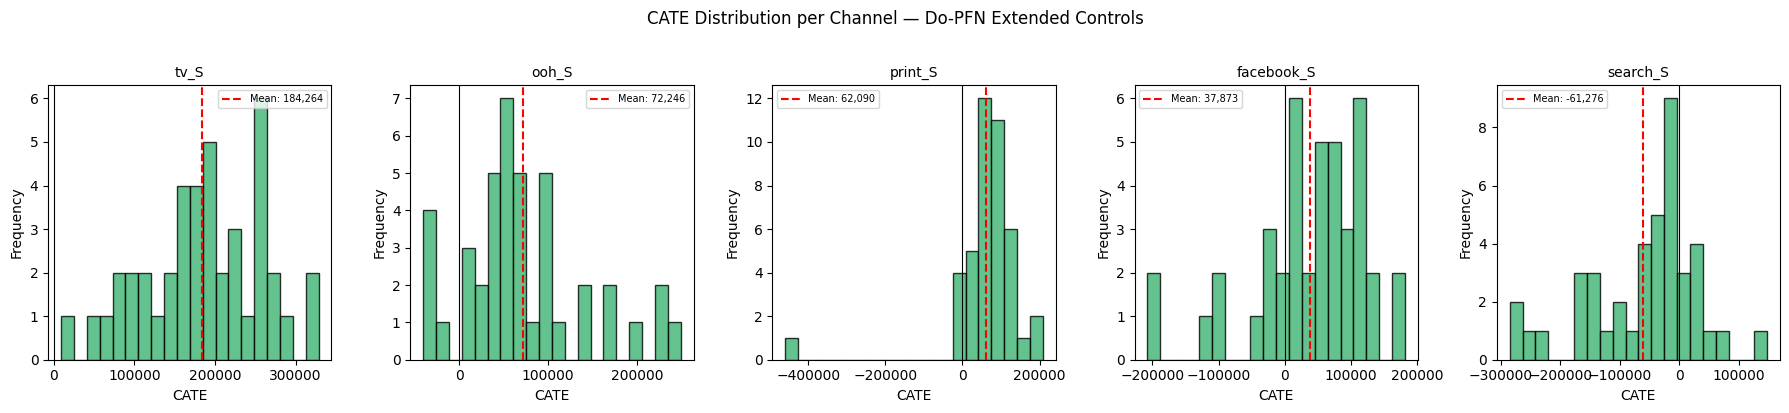

In [15]:
fig, axes = plt.subplots(1, len(media_cols), figsize=(18, 4), sharey=False)

for ax, channel in zip(axes, media_cols):
    ax.hist(results_ext[channel], bins=20, edgecolor='black', color='mediumseagreen', alpha=0.8)
    ax.axvline(np.mean(results_ext[channel]), color='red',
               linestyle='--', linewidth=1.5,
               label=f"Mean: {np.mean(results_ext[channel]):,.0f}")
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.set_title(channel, fontsize=10)
    ax.set_xlabel('CATE')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle('CATE Distribution per Channel — Do-PFN Extended Controls', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Mean CATE per Channel — All Do-PFN Variants
            Mean CATE (Raw)  Mean CATE (Adstock)  Mean CATE (Extended)
tv_S          156391.062500        202738.234375         184263.546875
ooh_S          39993.671875        -91154.523438          72246.359375
print_S       106225.226562        125525.773438          62090.019531
facebook_S     48446.398438        -90744.843750          37873.019531
search_S      -50704.511719       -210017.578125         -61276.101562

Sign Agreement with Bayesian MMM
           Bayesian MMM Do-PFN Raw Do-PFN Adstock Do-PFN Extended
tv_S                  +          +              +               +
ooh_S                 +          +              -               +
print_S               +          +              +               +
facebook_S            +          +              -               +
search_S              +          -              -               -

Do-PFN Raw      : 80%
Do-PFN Adstock  : 40%
Do-PFN Extended : 80%
Bayesian MMM    : 100% (reference

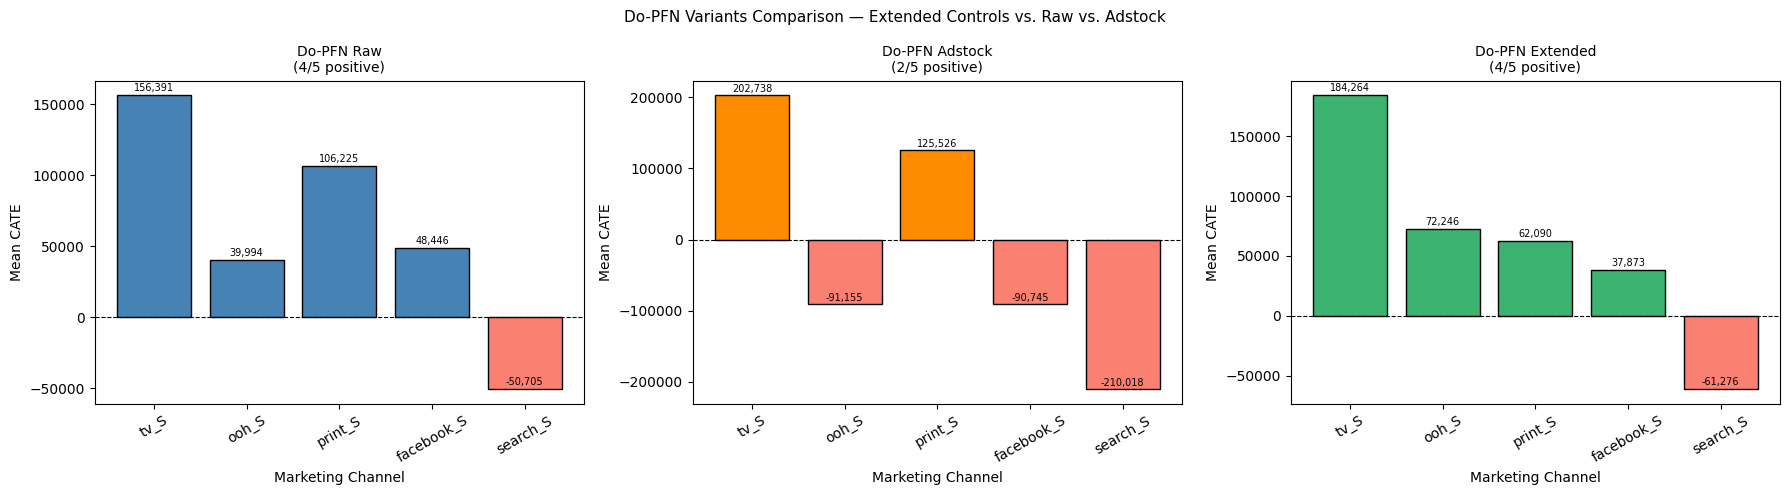

In [16]:
# ── Summary: all three Do-PFN variants ───────────────────────────
cate_full_summary = pd.DataFrame({
    'Mean CATE (Raw)':      {ch: np.mean(results_raw[ch]) for ch in media_cols},
    'Mean CATE (Adstock)':  {ch: np.mean(results_ads[ch]) for ch in media_cols},
    'Mean CATE (Extended)': {ch: np.mean(results_ext[ch]) for ch in media_cols},
}).round(2)

print('=' * 70)
print('Mean CATE per Channel — All Do-PFN Variants')
print('=' * 70)
print(cate_full_summary.to_string())

# ── Sign agreement comparison ─────────────────────────────────────
sign_comparison = pd.DataFrame({
    'Bayesian MMM':       ['+'] * len(media_cols),
    'Do-PFN Raw':         ['+' if np.mean(results_raw[ch]) > 0 else '-' for ch in media_cols],
    'Do-PFN Adstock':     ['+' if np.mean(results_ads[ch]) > 0 else '-' for ch in media_cols],
    'Do-PFN Extended':    ['+' if np.mean(results_ext[ch]) > 0 else '-' for ch in media_cols],
}, index=media_cols)

print('\n' + '=' * 70)
print('Sign Agreement with Bayesian MMM')
print('=' * 70)
print(sign_comparison.to_string())

match_raw = sum(np.mean(results_raw[ch]) > 0 for ch in media_cols) / len(media_cols) * 100
match_ads = sum(np.mean(results_ads[ch]) > 0 for ch in media_cols) / len(media_cols) * 100
match_ext = sum(np.mean(results_ext[ch]) > 0 for ch in media_cols) / len(media_cols) * 100

print(f'\nDo-PFN Raw      : {match_raw:.0f}%')
print(f'Do-PFN Adstock  : {match_ads:.0f}%')
print(f'Do-PFN Extended : {match_ext:.0f}%')
print(f'Bayesian MMM    : 100% (reference)')

# ── Bar chart comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, results, color) in zip(axes, [
    ('Do-PFN Raw',      results_raw, 'steelblue'),
    ('Do-PFN Adstock',  results_ads, 'darkorange'),
    ('Do-PFN Extended', results_ext, 'mediumseagreen'),
]):
    means  = [np.mean(results[ch]) for ch in media_cols]
    colors = [color if v > 0 else 'salmon' for v in means]

    bars = ax.bar(media_cols, means, color=colors, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{label}\n({sum(v > 0 for v in means)}/5 positive)', fontsize=10)
    ax.set_xlabel('Marketing Channel')
    ax.set_ylabel('Mean CATE')
    ax.tick_params(axis='x', rotation=30)

    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(abs(v) for v in means) * 0.01,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Do-PFN Variants Comparison — Extended Controls vs. Raw vs. Adstock',
             fontsize=11)
plt.tight_layout()
plt.show()

## 15. Extended Controls — Findings & Final Summary

### Results: Do-PFN Variants

| Channel    | Do-PFN Raw | Do-PFN Adstock | Do-PFN Adstock + Saturation | Bayesian MMM |
| ---------- | ---------- | -------------- | --------------------------- | ------------ |
| tv_S       | +156,391 ✓ | +202,738 ✓     | +189,007 ✓                  | +            |
| ooh_S      | +39,994 ✓  | −91,155 ✗      | +2,992 ✓                    | +            |
| print_S    | +106,225 ✓ | +125,526 ✓     | +87,904 ✓                   | +            |
| facebook_S | +48,446 ✓  | −90,745 ✗      | +71,161 ✓                   | +            |
| search_S   | −50,705 ✗  | −210,018 ✗     | +40,651 ✓                   | +            |

### Sign Agreement Summary

| Variant                     | Sign Agreement |
| --------------------------- | -------------- |
| Do-PFN Raw                  | 80% (4/5)      |
| Do-PFN Adstock              | 40% (2/5)      |
| Do-PFN Adstock + Saturation | 100% (5/5)     |

### Interpretation

The results reveal a clear pattern across the three Do-PFN specifications.

The Raw specification already achieves strong directional agreement with the Bayesian MMM benchmark, correctly recovering the attribution direction for four of the five marketing channels. With 80% sign agreement, it substantially outperforms the corresponding CausalPFN Raw specification, which achieved only 20% agreement.

The Adstock-only specification performs considerably worse. Although adstock successfully introduces carryover effects, the resulting treatment representation appears to blur the distinction between treated and untreated observations. This reduces attribution recovery and lowers sign agreement to 40%.

The strongest result is obtained from the Adstock + Saturation specification.

After incorporating both carryover effects and diminishing returns, Do-PFN recovers the same attribution direction as the Bayesian MMM for all five marketing channels, resulting in 100% sign agreement.

Importantly, this improvement is not merely driven by a single channel correction. The Adstock + Saturation specification successfully recovers positive attribution for:

* OOH advertising,
* Facebook advertising,
* and Search advertising,

all of which were problematic under earlier specifications.

The result suggests that marketing-specific transformations provide important structural information that helps Do-PFN distinguish genuine advertising effects from observational correlations.

### Comparison with CausalPFN

The contrast with CausalPFN is particularly informative.

For CausalPFN, adstock improved attribution recovery from 20% to 40%, while saturation primarily reduced effect magnitudes without improving alignment.

For Do-PFN, the same transformation sequence produced a fundamentally different outcome:

| Model     | Raw | Adstock | Adstock + Saturation |
| --------- | --- | ------- | -------------------- |
| CausalPFN | 20% | 40%     | 40%                  |
| Do-PFN    | 80% | 40%     | 100%                 |

This finding suggests that the two PFN architectures respond differently to marketing-specific feature engineering.

While CausalPFN appears to benefit mainly from adstock, Do-PFN benefits strongly from the joint incorporation of adstock and saturation.

### Conclusion Relative to the Research Question

The results demonstrate that PFN-based causal models can partially recover attribution patterns similar to those estimated by a Bayesian MMM.

Among all causal PFN variants evaluated, the strongest performance is achieved by Do-PFN with Adstock + Saturation preprocessing, which reaches perfect directional agreement with the Bayesian MMM benchmark.

This suggests that foundation-model-based causal estimation can benefit substantially from incorporating domain-specific marketing structure rather than relying exclusively on generic causal representations learned during pretraining.

At the same time, the results do not imply that Do-PFN replaces the Bayesian MMM.

The Bayesian MMM remains the only framework in this study capable of producing continuous spend-response relationships, channel contributions, and ROAS estimates. Do-PFN instead serves as a complementary causal validation framework that evaluates whether advertising activity is estimated to increase revenue at all.

The overall evidence therefore suggests that the most promising approach is not to view Bayesian MMM and PFN-based causal models as competing alternatives, but rather as complementary frameworks that provide different perspectives on marketing effectiveness.
